# Student-entropy ROC AUC dynamics

This notebook tracks how well the student's single-token answer entropy separates correct from incorrect MMLU answers over training. A correct answer is the positive class, and negative student entropy is the only ROC score: lower entropy means greater estimated likelihood of correctness.

The comparison includes three strategies that re-estimate complexity every epoch: `entropy_gain_proportional` (Entropy gain proportional), `entropy_gain` (Entropy gain), and `student_entropy` (Student entropy). Each comparison shows Llama 3B, Phi-4 Mini, and Qwen 3B individually, followed by a separate aggregate graph across all three models.

Entropy gain proportional uses the `<model>_shuffle` run directories and their matching `_shuffle_seedNN` replicas. The other strategies use `<model>` and `<model>_seedNN`. Replicas without any complexity-estimation Parquets are reported and excluded; evaluation summaries alone cannot supply entropy ROC AUC. All numeric epoch directories are loaded without a fixed epoch limit; each must contain exactly one complexity-estimation Parquet. Base runs use seed 42. Only `entropy_gain_proportional` has a 95% Student-t confidence interval: individual-model curves calculate it across seeds; aggregate curves first average the three models within each seed, then calculate the mean and CI across those seed averages. At least two valid seeds are required for a CI. The deterministic strategies show equal-weight model means without confidence intervals.

The horizontal axis uses training samples seen, matching `distillation_by_metrics.ipynb`: epoch × the run’s `_topk<N>` value, or 1,024 samples per epoch by default. Entropy is measured before that epoch’s training, so epoch 0 corresponds to zero samples. The 256-row single-token mix is excluded from this shared sample-count convention.


In [3]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import t as student_t
from sklearn.metrics import roc_auc_score

for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    source_dir = directory / "src"
    if (source_dir / "core").is_dir():
        sys.path.insert(0, str(source_dir))
        break
else:
    raise FileNotFoundError("Could not find the repository's src/core directory")

from core.utils.graph_style import set_style

set_style()

ARTIFACT_GROUP = "distillation_by_metrics/mmlu"
EXPERIMENTS = (
    "entropy_gain_proportional",
    "entropy_gain",
    "student_entropy",
)
SCORE_COLUMN = "entropy_value"
TEACHER_ENTROPY_COLUMN = "teacher_entropy"
CORRECTNESS_COLUMN = "estimation_phase_answer_correctness"
DEFAULT_SAMPLES_PER_EPOCH = 1024
TOPK_RE = re.compile(r"(?:^|_)topk(\d+)(?=_|$)")
TOP_K_SUBSETS = (1024, 2048)
BASE_SEED = 42
CONFIDENCE_LEVEL = 0.95
STOCHASTIC_EXPERIMENT = "entropy_gain_proportional"

EXPERIMENT_LABELS = {
    "entropy_gain": "Entropy gain (deterministic)",
    "entropy_gain_proportional": "Entropy gain (sampled)",
    "student_entropy": "Student entropy (deterministic)",
}
RUN_DIRECTORY_SUFFIXES = {"entropy_gain_proportional": "_shuffle"}
MODEL_LABELS = {
    "llama_3b_head_truncated8192": "Llama 3B",
    "phi4_mini_head_truncated8192": "Phi-4 Mini",
    "qwen_3b_head_truncated8192": "Qwen 3B",
}

In [4]:
def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk upward from the current directory until artifacts/ is found."""
    start = (start or Path.cwd()).resolve()
    for directory in (start, *start.parents):
        candidate = directory / "artifacts"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find artifacts/ above {start}")


def discover_model_runs(experiment_dir: Path, model: str) -> list[tuple[Path, int]]:
    """Return the base run and exact seed replicas with complexity data."""
    run_name = model + RUN_DIRECTORY_SUFFIXES.get(experiment_dir.name, "")
    base_run = experiment_dir / run_name
    if not base_run.is_dir():
        raise FileNotFoundError(f"Missing base run directory: {base_run}")

    seed_pattern = re.compile(rf"^{re.escape(run_name)}_seed(?P<seed>\d+)$")
    runs = [(base_run, BASE_SEED)]
    for candidate in sorted(experiment_dir.iterdir()):
        match = seed_pattern.fullmatch(candidate.name)
        if candidate.is_dir() and match:
            complexity_parquets = candidate.glob("resampling_trainer_data/*/complexity_estimation/*.parquet")
            if next(complexity_parquets, None) is None:
                print(f"Excluded {experiment_dir.name}/{candidate.name}: no complexity-estimation Parquets available")
                continue
            runs.append((candidate, int(match.group("seed"))))

    seeds = [seed for _, seed in runs]
    if len(seeds) != len(set(seeds)):
        raise ValueError(f"Duplicate seeds for {experiment_dir.name}/{model}: {seeds}")
    return runs


def discover_run_epochs(run_dir: Path) -> tuple[int, ...]:
    """Find every numeric epoch directory, with no fixed training limit."""
    epoch_root = run_dir / "resampling_trainer_data"
    if not epoch_root.is_dir():
        raise FileNotFoundError(f"Missing resampling data directory: {epoch_root}")
    epochs = tuple(sorted(int(path.name) for path in epoch_root.iterdir() if path.is_dir() and path.name.isdecimal()))
    if not epochs:
        raise FileNotFoundError(f"No epoch directories found in {epoch_root}")
    return epochs


def samples_per_epoch(*run_names: str) -> int:
    """Match the sample-count convention in distillation_by_metrics.ipynb."""
    for run_name in run_names:
        if match := TOPK_RE.search(run_name):
            return int(match.group(1))
    return DEFAULT_SAMPLES_PER_EPOCH


def load_roc_auc_dynamics(group_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Load selected models and seed replicas across every available epoch."""
    records = []
    subset_records = []
    skipped = []

    for experiment in EXPERIMENTS:
        experiment_dir = group_dir / experiment
        if not experiment_dir.is_dir():
            raise FileNotFoundError(f"Missing experiment directory: {experiment_dir}")
        required_columns = [CORRECTNESS_COLUMN, SCORE_COLUMN, TEACHER_ENTROPY_COLUMN]

        for model in MODEL_LABELS:
            for run_dir, seed in discover_model_runs(experiment_dir, model):
                sample_scale = samples_per_epoch(experiment, run_dir.name)
                for epoch in discover_run_epochs(run_dir):
                    parquet_paths = sorted(
                        (run_dir / "resampling_trainer_data" / str(epoch) / "complexity_estimation").glob("*.parquet")
                    )
                    if len(parquet_paths) != 1:
                        raise FileNotFoundError(
                            f"Expected one parquet for {experiment}/{run_dir.name}/epoch {epoch}; "
                            f"found {len(parquet_paths)}"
                        )
                    parquet_path = parquet_paths[0]
                    epoch_df = pd.read_parquet(
                        parquet_path,
                        columns=required_columns,
                    ).dropna(subset=required_columns)

                    if epoch_df.empty:
                        skipped.append(f"{experiment}/{run_dir.name}/epoch {epoch}: no valid rows")
                        continue

                    answer_correct = epoch_df[CORRECTNESS_COLUMN].astype(bool).astype(int)
                    correctness_score = -epoch_df[SCORE_COLUMN]
                    entropy_gain = (epoch_df[SCORE_COLUMN] - epoch_df[TEACHER_ENTROPY_COLUMN]).clip(lower=0)
                    if answer_correct.nunique() != 2:
                        skipped.append(f"{experiment}/{run_dir.name}/epoch {epoch}: target has one class")
                        continue

                    records.append(
                        {
                            "experiment": experiment,
                            "model": model,
                            "run": run_dir.name,
                            "seed": seed,
                            "epoch": epoch,
                            "training_samples": epoch * sample_scale,
                            "roc_auc": roc_auc_score(answer_correct, correctness_score),
                            "num_valid": len(epoch_df),
                            "accuracy": answer_correct.mean(),
                            "target_classes": answer_correct.nunique(),
                        }
                    )

                    # Use the strategy's complexity score for subset membership;
                    # evaluate correctness using student entropy only.
                    if experiment == "student_entropy":
                        selection_score = epoch_df[SCORE_COLUMN]
                    else:
                        selection_score = entropy_gain
                    ranked_df = epoch_df.assign(
                        answer_correct=answer_correct,
                        entropy_gain=entropy_gain,
                        selection_score=selection_score,
                    ).sort_values("selection_score", ascending=False, kind="stable")
                    for top_k in TOP_K_SUBSETS:
                        selected = ranked_df.head(top_k)
                        if selected["answer_correct"].nunique() != 2:
                            skipped.append(
                                f"{experiment}/{run_dir.name}/epoch {epoch}/top {top_k}: target has one class"
                            )
                            continue
                        subset_records.append(
                            {
                                "experiment": experiment,
                                "model": model,
                                "run": run_dir.name,
                                "seed": seed,
                                "epoch": epoch,
                                "training_samples": epoch * sample_scale,
                                "subset_size": top_k,
                                "num_selected": len(selected),
                                "roc_auc": roc_auc_score(selected["answer_correct"], -selected[SCORE_COLUMN]),
                                "target_classes": selected["answer_correct"].nunique(),
                            }
                        )

    all_rows = (
        pd.DataFrame.from_records(records).sort_values(["model", "experiment", "seed", "epoch"]).reset_index(drop=True)
    )
    top_rows = (
        pd.DataFrame.from_records(subset_records)
        .sort_values(["subset_size", "model", "experiment", "seed", "epoch"])
        .reset_index(drop=True)
    )
    return all_rows, top_rows, skipped


def aggregate_seed_metrics(rows: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    """Average seeds; calculate 95% Student-t CIs only for proportional sampling."""
    aggregations = {"num_seeds": ("seed", "nunique")}
    for metric in ("roc_auc",):
        aggregations[metric] = (metric, "mean")
        aggregations[f"{metric}_std"] = (metric, "std")
    for column in ("num_valid", "num_selected", "accuracy"):
        if column in rows:
            aggregations[column] = (column, "mean")

    summary = rows.groupby(group_columns, as_index=False).agg(**aggregations)
    replicated = summary["experiment"].eq(STOCHASTIC_EXPERIMENT) & summary["num_seeds"].gt(1)
    critical_values = student_t.ppf(
        1 - (1 - CONFIDENCE_LEVEL) / 2,
        summary.loc[replicated, "num_seeds"] - 1,
    )
    for metric in ("roc_auc",):
        half_width = critical_values * (
            summary.loc[replicated, f"{metric}_std"] / np.sqrt(summary.loc[replicated, "num_seeds"])
        )
        summary[f"{metric}_ci_low"] = np.nan
        summary[f"{metric}_ci_high"] = np.nan
        summary.loc[replicated, f"{metric}_ci_low"] = (summary.loc[replicated, metric] - half_width).clip(lower=0)
        summary.loc[replicated, f"{metric}_ci_high"] = (summary.loc[replicated, metric] + half_width).clip(upper=1)
    return summary.sort_values(group_columns).reset_index(drop=True)


ARTIFACTS_DIR = find_artifacts_dir()
GROUP_DIR = ARTIFACTS_DIR / ARTIFACT_GROUP
seed_roc_auc_by_epoch, seed_subset_roc_auc_by_epoch, skipped_epochs = load_roc_auc_dynamics(GROUP_DIR)
roc_auc_by_epoch = aggregate_seed_metrics(seed_roc_auc_by_epoch, ["model", "experiment", "epoch", "training_samples"])
subset_roc_auc_by_epoch = aggregate_seed_metrics(
    seed_subset_roc_auc_by_epoch, ["subset_size", "model", "experiment", "epoch", "training_samples"]
)
print(f"Loaded {len(seed_roc_auc_by_epoch):,} seed-epoch metrics from {GROUP_DIR}")
print(f"Calculated {len(seed_subset_roc_auc_by_epoch):,} seed/top-subset metrics")
print(f"Aggregated to {len(roc_auc_by_epoch):,} epoch means and {len(subset_roc_auc_by_epoch):,} top-subset means")
if skipped_epochs:
    print(f"Skipped {len(skipped_epochs)} invalid epoch(s):")
    print("\n".join(skipped_epochs))

Excluded entropy_gain_proportional/llama_3b_head_truncated8192_shuffle_seed44: no complexity-estimation Parquets available
Excluded entropy_gain_proportional/phi4_mini_head_truncated8192_shuffle_seed44: no complexity-estimation Parquets available
Excluded entropy_gain_proportional/qwen_3b_head_truncated8192_shuffle_seed44: no complexity-estimation Parquets available
Loaded 2,400 seed-epoch metrics from /Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics/mmlu
Calculated 4,721 seed/top-subset metrics
Aggregated to 1,800 epoch means and 3,560 top-subset means
Skipped 79 invalid epoch(s):
entropy_gain_proportional/phi4_mini_head_truncated8192_shuffle/epoch 164/top 1024: target has one class
entropy_gain_proportional/phi4_mini_head_truncated8192_shuffle/epoch 165/top 1024: target has one class
entropy_gain_proportional/phi4_mini_head_truncated8192_shuffle/epoch 166/top 1024: target has one class
entropy_gain_proportional/phi4_mini_head_truncated8192_shuffle/epoch 

In [5]:
models = sorted(seed_roc_auc_by_epoch["model"].unique())
expected_runs = {(experiment, model) for experiment in EXPERIMENTS for model in MODEL_LABELS}
observed_runs = set(seed_roc_auc_by_epoch[["experiment", "model"]].itertuples(index=False, name=None))

skipped_subsets = {message.rsplit(": ", 1)[0] for message in skipped_epochs if "/top " in message}
assert all("/top " in message for message in skipped_epochs), "Every full epoch should have usable two-class data"
assert set(models) == set(MODEL_LABELS), f"Unexpected models: {models}"
assert observed_runs == expected_runs, f"Unexpected run set: {observed_runs}"
assert pd.api.types.is_integer_dtype(seed_roc_auc_by_epoch["epoch"])
assert seed_roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert seed_roc_auc_by_epoch["num_valid"].gt(0).all()
assert seed_roc_auc_by_epoch["target_classes"].eq(2).all()
assert not seed_roc_auc_by_epoch.duplicated(["experiment", "model", "seed", "epoch"]).any()
expected_seed_rows = 0
for (experiment, model, seed), run in seed_roc_auc_by_epoch.groupby(["experiment", "model", "seed"]):
    run_dir = GROUP_DIR / experiment / run["run"].iloc[0]
    expected_epochs = set(discover_run_epochs(run_dir))
    assert set(run["epoch"]) == expected_epochs
    assert run["training_samples"].eq(run["epoch"] * samples_per_epoch(experiment, run_dir.name)).all()
    expected_seed_rows += len(expected_epochs)

seed_runs = seed_roc_auc_by_epoch[["experiment", "model", "seed"]].drop_duplicates()
assert len(seed_roc_auc_by_epoch) == expected_seed_rows
assert len(seed_subset_roc_auc_by_epoch) == expected_seed_rows * len(TOP_K_SUBSETS) - len(skipped_subsets)
assert set(seed_subset_roc_auc_by_epoch["subset_size"]) == set(TOP_K_SUBSETS)
assert seed_subset_roc_auc_by_epoch["num_selected"].eq(seed_subset_roc_auc_by_epoch["subset_size"]).all()
assert seed_subset_roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert seed_subset_roc_auc_by_epoch["target_classes"].eq(2).all()
for (subset_size, experiment, model, seed), run in seed_subset_roc_auc_by_epoch.groupby(
    ["subset_size", "experiment", "model", "seed"]
):
    run_dir = GROUP_DIR / experiment / run["run"].iloc[0]
    expected_epochs = {
        epoch
        for epoch in discover_run_epochs(run_dir)
        if f"{experiment}/{run_dir.name}/epoch {epoch}/top {subset_size}" not in skipped_subsets
    }
    assert set(run["epoch"]) == expected_epochs
    assert run["training_samples"].eq(run["epoch"] * samples_per_epoch(experiment, run_dir.name)).all()

replicated = roc_auc_by_epoch["experiment"].eq(STOCHASTIC_EXPERIMENT) & roc_auc_by_epoch["num_seeds"].gt(1)
for metric in ("roc_auc",):
    assert roc_auc_by_epoch.loc[replicated, [f"{metric}_ci_low", f"{metric}_ci_high"]].notna().all().all()
    assert roc_auc_by_epoch.loc[~replicated, [f"{metric}_ci_low", f"{metric}_ci_high"]].isna().all().all()

seed_coverage = (
    seed_runs.groupby(["model", "experiment"])["seed"]
    .agg(lambda seeds: ", ".join(map(str, sorted(seeds))))
    .rename("Seeds")
    .reset_index()
)
seed_coverage["model"] = seed_coverage["model"].map(MODEL_LABELS)
seed_coverage["experiment"] = seed_coverage["experiment"].map(EXPERIMENT_LABELS)
display(seed_coverage.rename(columns={"model": "Model", "experiment": "Strategy"}))
print(
    f"Validated {len(seed_runs)} seeded runs across {len(MODEL_LABELS)} models × "
    f"{len(EXPERIMENTS)} strategies: {expected_seed_rows:,} available seed-epochs, "
    f"up to {seed_roc_auc_by_epoch['training_samples'].max():,} training samples."
)
print(
    f"Validated exact top-1,024 and top-2,048 subsets wherever ROC AUC is defined; "
    f"{len(skipped_subsets)} one-class subset(s) excluded."
)

,Model,Strategy,Seeds
0,Llama 3B,Entropy gain (deterministic),42
1,Llama 3B,Entropy gain (sampled),"42, 43"
2,Llama 3B,Student entropy (deterministic),42
3,Phi-4 Mini,Entropy gain (deterministic),42
4,Phi-4 Mini,Entropy gain (sampled),"42, 43"
5,Phi-4 Mini,Student entropy (deterministic),42
6,Qwen 3B,Entropy gain (deterministic),42
7,Qwen 3B,Entropy gain (sampled),"42, 43"
8,Qwen 3B,Student entropy (deterministic),42


Validated 12 seeded runs across 3 models × 3 strategies: 2,400 available seed-epochs, up to 203,776 training samples.
Validated exact top-1,024 and top-2,048 subsets wherever ROC AUC is defined; 79 one-class subset(s) excluded.


In [6]:
summary = (
    roc_auc_by_epoch.sort_values("epoch")
    .groupby(["model", "experiment"], as_index=False)
    .agg(
        initial_training_samples=("training_samples", "first"),
        initial_roc_auc=("roc_auc", "first"),
        initial_ci_low=("roc_auc_ci_low", "first"),
        initial_ci_high=("roc_auc_ci_high", "first"),
        final_training_samples=("training_samples", "last"),
        final_roc_auc=("roc_auc", "last"),
        final_ci_low=("roc_auc_ci_low", "last"),
        final_ci_high=("roc_auc_ci_high", "last"),
        peak_roc_auc=("roc_auc", "max"),
        num_seeds=("num_seeds", "max"),
        min_valid_samples=("num_valid", "min"),
    )
)
summary["model"] = summary["model"].map(MODEL_LABELS)
summary["experiment"] = summary["experiment"].map(EXPERIMENT_LABELS)
display(
    summary.rename(columns={"model": "Model", "experiment": "Strategy"}).style.format(
        {
            "initial_training_samples": "{:,.0f}",
            "final_training_samples": "{:,.0f}",
            "initial_roc_auc": "{:.3f}",
            "initial_ci_low": "{:.3f}",
            "initial_ci_high": "{:.3f}",
            "final_roc_auc": "{:.3f}",
            "final_ci_low": "{:.3f}",
            "final_ci_high": "{:.3f}",
            "peak_roc_auc": "{:.3f}",
            "min_valid_samples": "{:,.0f}",
        }
    )
)

,Model,Strategy,initial_training_samples,initial_roc_auc,initial_ci_low,initial_ci_high,final_training_samples,final_roc_auc,final_ci_low,final_ci_high,peak_roc_auc,num_seeds,min_valid_samples
0,Llama 3B,Entropy gain (deterministic),0,0.707,nan,nan,"203,776",0.616,nan,nan,0.779,1,"9,378"
1,Llama 3B,Entropy gain (sampled),0,0.708,0.699,0.717,"203,776",0.703,0.573,0.834,0.878,2,"9,620"
2,Llama 3B,Student entropy (deterministic),0,0.707,nan,nan,"203,776",0.402,nan,nan,0.737,1,"9,615"
3,Phi-4 Mini,Entropy gain (deterministic),0,0.732,nan,nan,"203,776",0.630,nan,nan,0.811,1,"9,625"
4,Phi-4 Mini,Entropy gain (sampled),0,0.735,0.735,0.735,"203,776",0.711,0.585,0.837,0.863,2,"9,626"
5,Phi-4 Mini,Student entropy (deterministic),0,0.732,nan,nan,"203,776",0.392,nan,nan,0.766,1,"9,624"
6,Qwen 3B,Entropy gain (deterministic),0,0.710,nan,nan,"203,776",0.600,nan,nan,0.781,1,"7,256"
7,Qwen 3B,Entropy gain (sampled),0,0.711,0.708,0.714,"203,776",0.766,0.503,1.000,0.891,2,"9,276"
8,Qwen 3B,Student entropy (deterministic),0,0.709,nan,nan,"203,776",0.412,nan,nan,0.759,1,"8,870"


In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

PLOTS_DIR = GROUP_DIR / "plots"
SCORE_LABEL = "Student entropy"
STRATEGY_COLORS = {experiment: plt.get_cmap("tab10")(i) for i, experiment in enumerate(EXPERIMENTS)}


def aggregate_model_metrics(seed_rows: pd.DataFrame) -> pd.DataFrame:
    """Average models within each proportional-sampling seed, then form its CI."""
    stochastic = seed_rows["experiment"].eq(STOCHASTIC_EXPERIMENT)
    per_seed_means = (
        seed_rows.loc[stochastic]
        .groupby(["experiment", "seed", "training_samples"], as_index=False)
        .agg(
            roc_auc=("roc_auc", "mean"),
            num_models=("model", "nunique"),
        )
    )
    # Each seed average must contain all three models, with equal model weights.
    per_seed_means = per_seed_means.loc[per_seed_means["num_models"].eq(len(MODEL_LABELS))]
    stochastic_summary = aggregate_seed_metrics(per_seed_means, ["experiment", "training_samples"])
    stochastic_summary["num_models"] = len(MODEL_LABELS)

    # Deterministic strategies have a model average, with no uncertainty band.
    model_means = (
        seed_rows.loc[~stochastic]
        .groupby(["experiment", "model", "training_samples"], as_index=False)
        .agg(roc_auc=("roc_auc", "mean"))
    )
    deterministic_summary = model_means.groupby(["experiment", "training_samples"], as_index=False).agg(
        roc_auc=("roc_auc", "mean"),
        num_models=("model", "nunique"),
    )
    deterministic_summary = deterministic_summary.loc[deterministic_summary["num_models"].eq(len(MODEL_LABELS))].copy()
    deterministic_summary["roc_auc_ci_low"] = np.nan
    deterministic_summary["roc_auc_ci_high"] = np.nan
    return (
        pd.concat([stochastic_summary, deterministic_summary], ignore_index=True)
        .sort_values(["experiment", "training_samples"])
        .reset_index(drop=True)
    )


def plot_strategy_curves(ax, rows: pd.DataFrame):
    for experiment in EXPERIMENTS:
        curve = rows[rows["experiment"] == experiment].sort_values("training_samples")
        ax.plot(
            curve["training_samples"],
            curve["roc_auc"],
            color=STRATEGY_COLORS[experiment],
            linewidth=2.2,
        )
        if experiment == STOCHASTIC_EXPERIMENT and curve["roc_auc_ci_low"].notna().any():
            ax.fill_between(
                curve["training_samples"],
                curve["roc_auc_ci_low"],
                curve["roc_auc_ci_high"],
                color=STRATEGY_COLORS[experiment],
                alpha=0.12,
                linewidth=0,
            )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_xlabel("Training samples seen")
    assert len(ax.lines) - 1 == len(EXPERIMENTS)


def add_comparison_legend(fig, confidence_label: str):
    handles = [
        Line2D(
            [0],
            [0],
            color=STRATEGY_COLORS[experiment],
            linewidth=2.5,
            label=EXPERIMENT_LABELS[experiment],
        )
        for experiment in EXPERIMENTS
    ]
    # handles.append(Patch(color="gray", alpha=0.2, label=confidence_label))
    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.99),
        frameon=False,
    )


def save_and_display_figure(fig, title: str, filename: str):
    """Save a title-free PDF and show its title as separate notebook text."""
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(PLOTS_DIR / filename, format="pdf", bbox_inches="tight")
    display(Markdown(f"### {title}"))
    display(fig)
    plt.close(fig)


def plot_model_comparison(rows: pd.DataFrame, seed_rows: pd.DataFrame, title: str, filename_stem: str):
    """Show the three models individually, then a separate aggregate graph."""
    aggregate = aggregate_model_metrics(seed_rows)
    max_training_samples = rows["training_samples"].max()
    lower_limit = min(0.48, rows["roc_auc"].min() - 0.02, aggregate["roc_auc"].min() - 0.02)
    fig, axes = plt.subplots(1, len(models), figsize=(30, 10), sharex=True, sharey=True)
    for ax, model in zip(axes, models, strict=True):
        plot_strategy_curves(ax, rows[rows["model"] == model])
        ax.set_ylim(lower_limit, 1.0)
    axes[0].set_xlim(0, max_training_samples)
    axes[0].set_ylabel("Correct-answer ROC AUC")
    add_comparison_legend(fig, "95% CI across seeds")
    fig.subplots_adjust(left=0.07, right=0.99, bottom=0.11, top=0.82, wspace=0.06)
    model_names = ", ".join(MODEL_LABELS[model] for model in models)
    save_and_display_figure(
        fig,
        f"{title} — Score: {SCORE_LABEL}\n\nIndividual models, left to right: {model_names}.",
        f"{filename_stem}_individual_models.pdf",
    )

    fig, ax = plt.subplots(figsize=(14, 10))
    plot_strategy_curves(ax, aggregate)
    ax.set_xlim(0, max_training_samples)
    ax.set_ylabel("Correct-answer ROC AUC")
    ax.set_ylim(lower_limit, 1.0)
    add_comparison_legend(fig, "95% CI across seed averages")
    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.11, top=0.82)
    save_and_display_figure(
        fig,
        f"{title} — Score: {SCORE_LABEL}\n\nAll models (equal-weight mean).",
        f"{filename_stem}_all_models.pdf",
    )


## Individual models and aggregate comparison

Only the Student entropy score is displayed for Entropy gain proportional, Entropy gain, and Student entropy strategies. Individual-model shading is shown only for `entropy_gain_proportional` and represents a 95% Student-t CI across seeds. Its aggregate graph first takes the equal-weight mean of Llama 3B, Phi-4 Mini, and Qwen 3B within each seed, then calculates the mean and 95% Student-t CI across those seed averages. Entropy gain and Student entropy show only their equal-weight model averages, without shading.

Figures are saved as PDFs in `artifacts/distillation_by_metrics/mmlu/plots`. Titles and model-panel names are displayed separately above each figure, so they are excluded from both the PDFs and copied plot images.


### ROC AUC over training samples — Score: Student entropy

Individual models, left to right: Llama 3B, Phi-4 Mini, Qwen 3B.

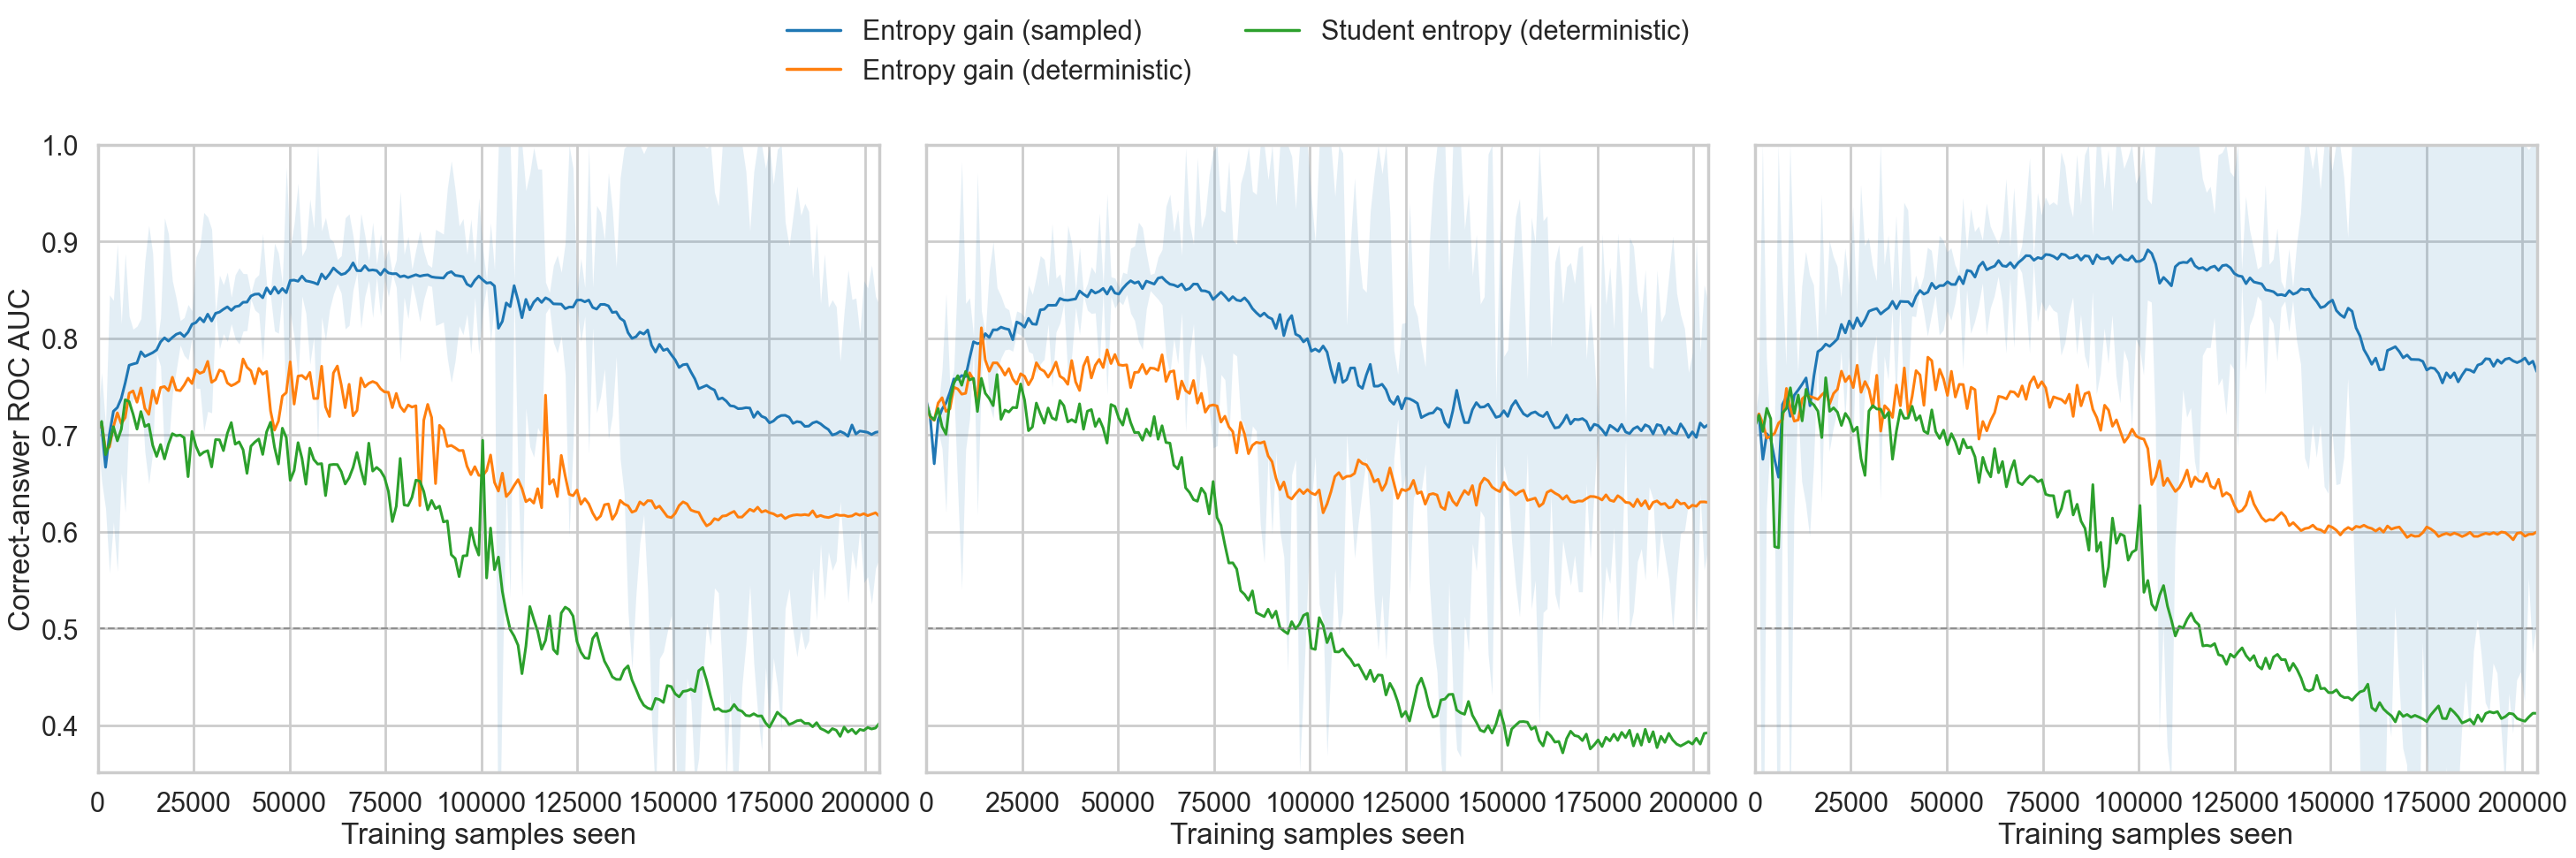

### ROC AUC over training samples — Score: Student entropy

All models (equal-weight mean).

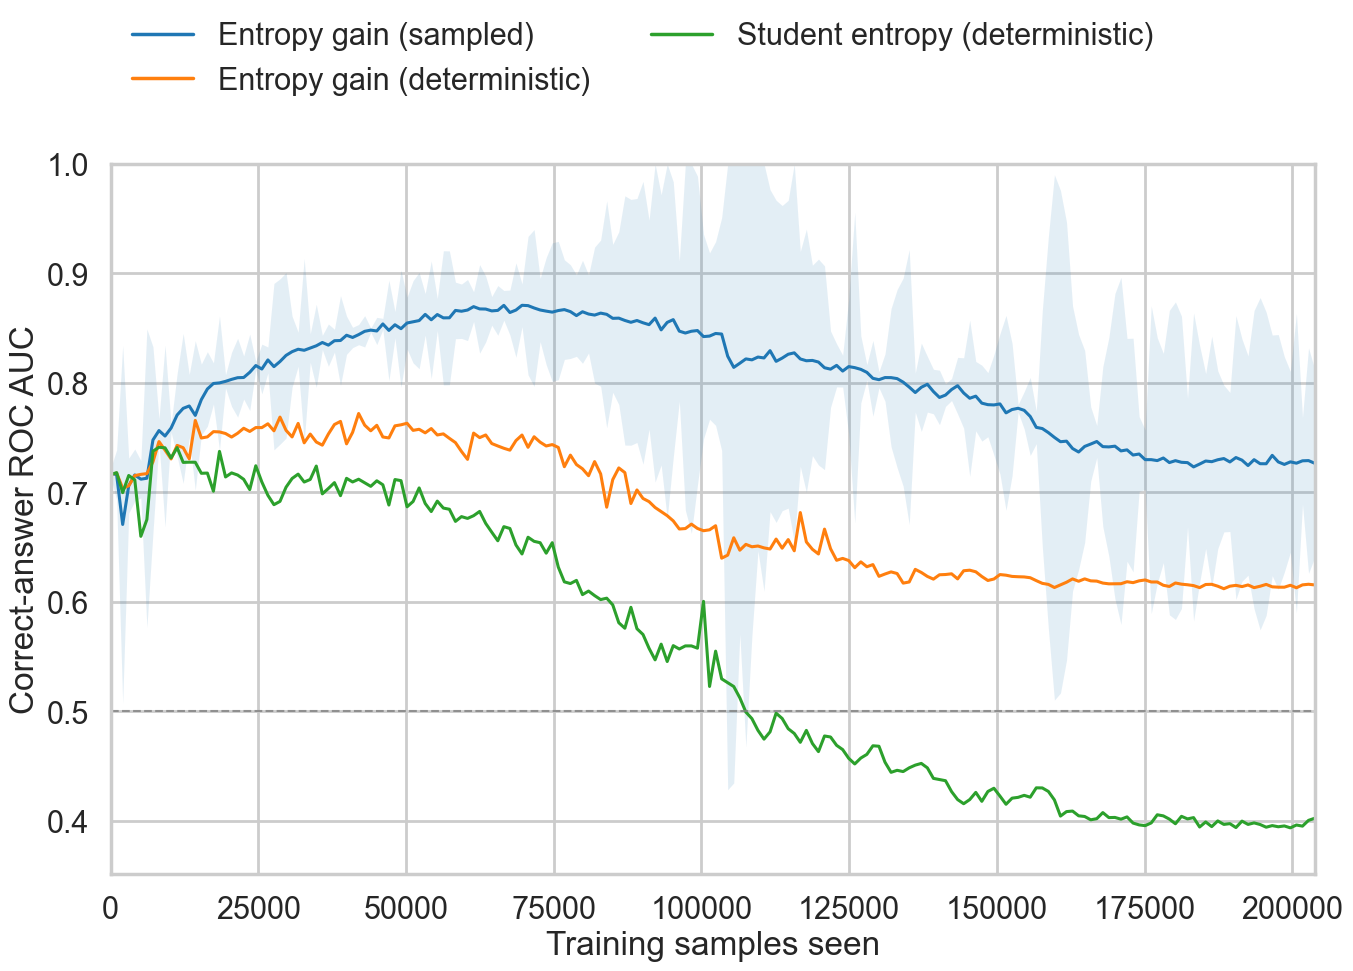

In [8]:
plot_model_comparison(
    roc_auc_by_epoch,
    seed_roc_auc_by_epoch,
    "ROC AUC over training samples",
    "student_entropy_roc_auc",
)


## ROC AUC within top-complexity subsets

The following comparisons restrict each available epoch to exactly the top 1,024 or top 2,048 rows. Student entropy runs are ranked by student entropy, and both entropy-gain strategies are ranked by `max(entropy_value - teacher_entropy, 0)`. The teacher entropy is the row-wise average of normalized Llama 70B and Qwen 72B single-token entropies.

The selection score controls only subset membership: ROC AUC is recomputed using Student entropy for all three strategies. Each comparison shows the three models individually and a separate equally weighted aggregate graph. Only `entropy_gain_proportional` has shading: individual-model CIs use seed replicas, and aggregate CIs use the per-seed averages of all three models. The deterministic strategies have no confidence intervals. Proportional sampling race keys and the experiment's separate 256-row single-token mix are excluded.

Subsets containing only correct or only incorrect answers have undefined ROC AUC and are reported and excluded. Individual-model means use valid replicas at each sample count. For the proportional-sampling aggregate, a seed contributes only when all three models have valid results at that sample count; its CI is omitted when fewer than two complete seed averages remain. Deterministic aggregate points also require all three models.


### ROC AUC within top-1,024 complexity subsets — Score: Student entropy

Individual models, left to right: Llama 3B, Phi-4 Mini, Qwen 3B.

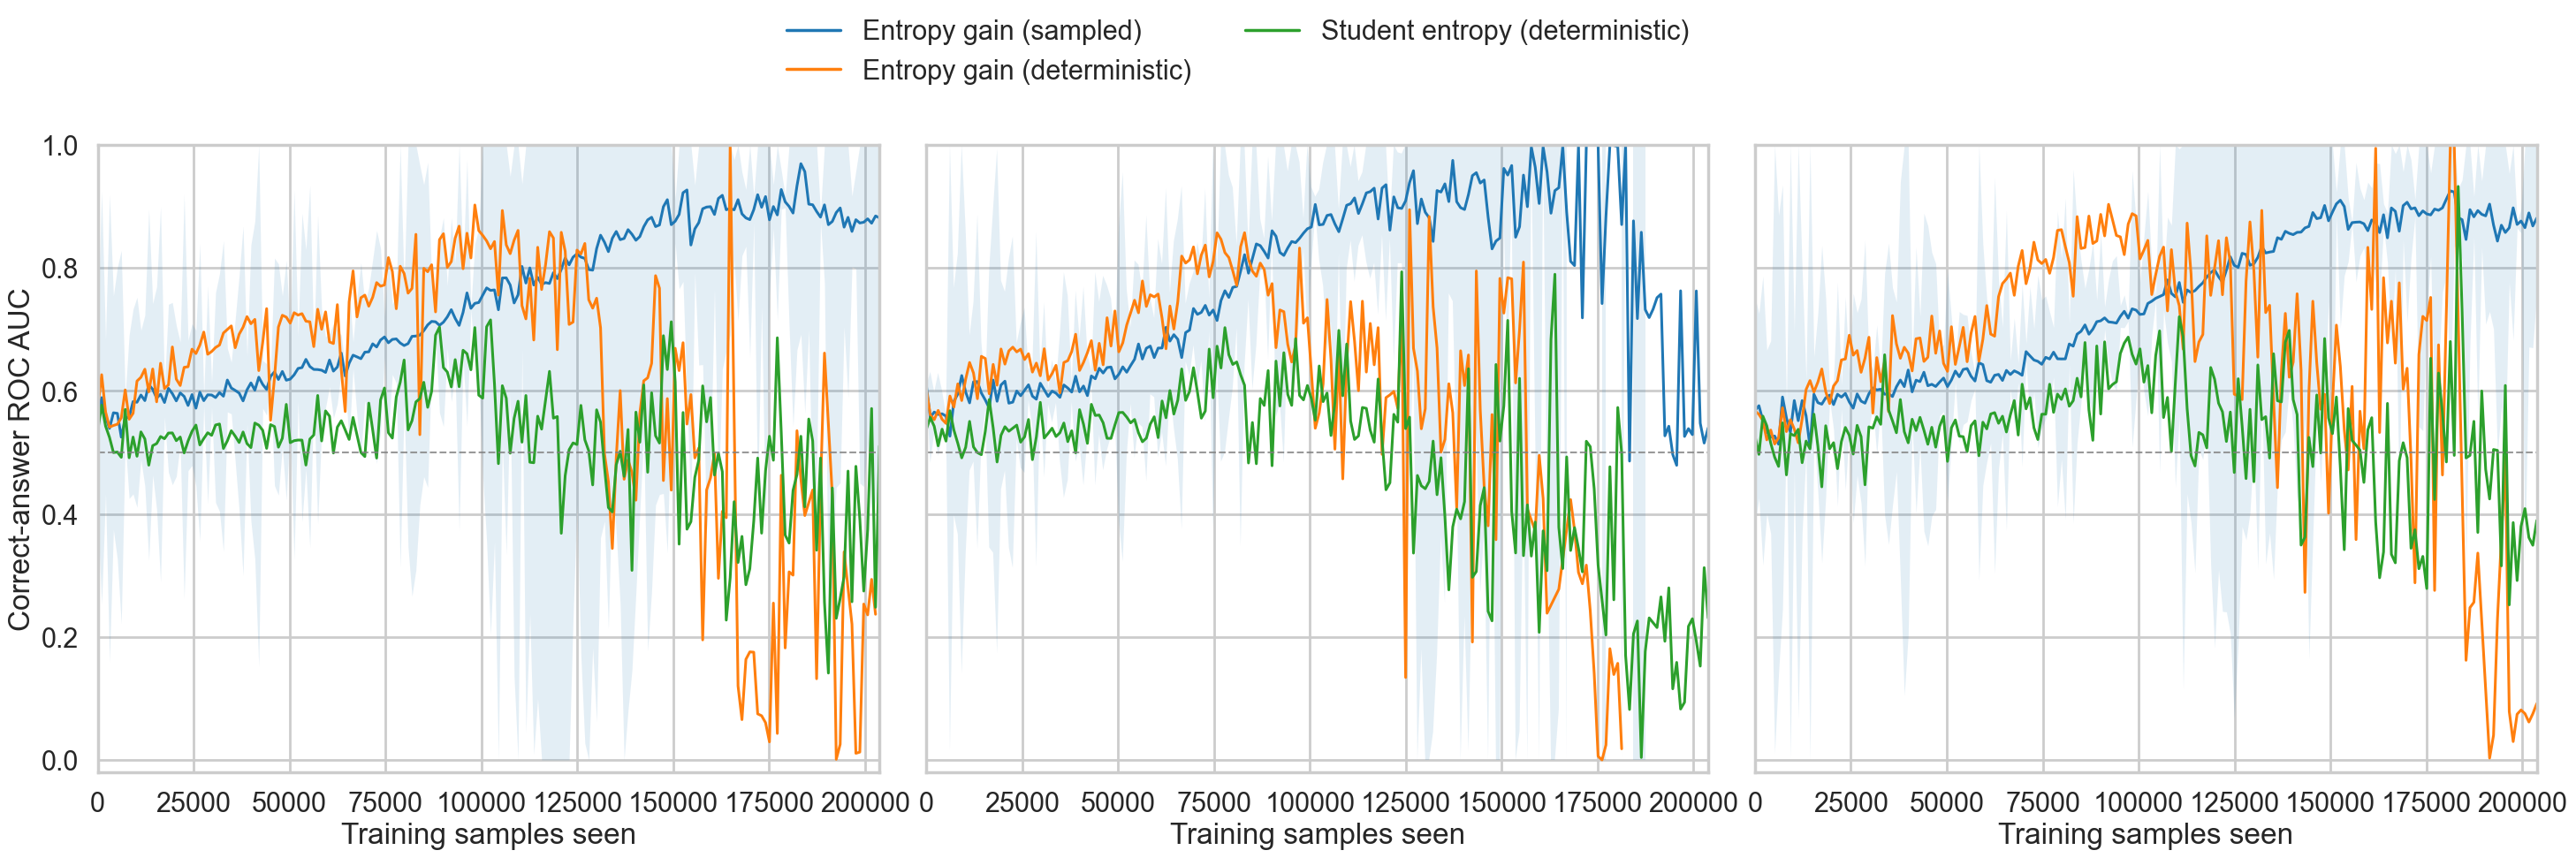

### ROC AUC within top-1,024 complexity subsets — Score: Student entropy

All models (equal-weight mean).

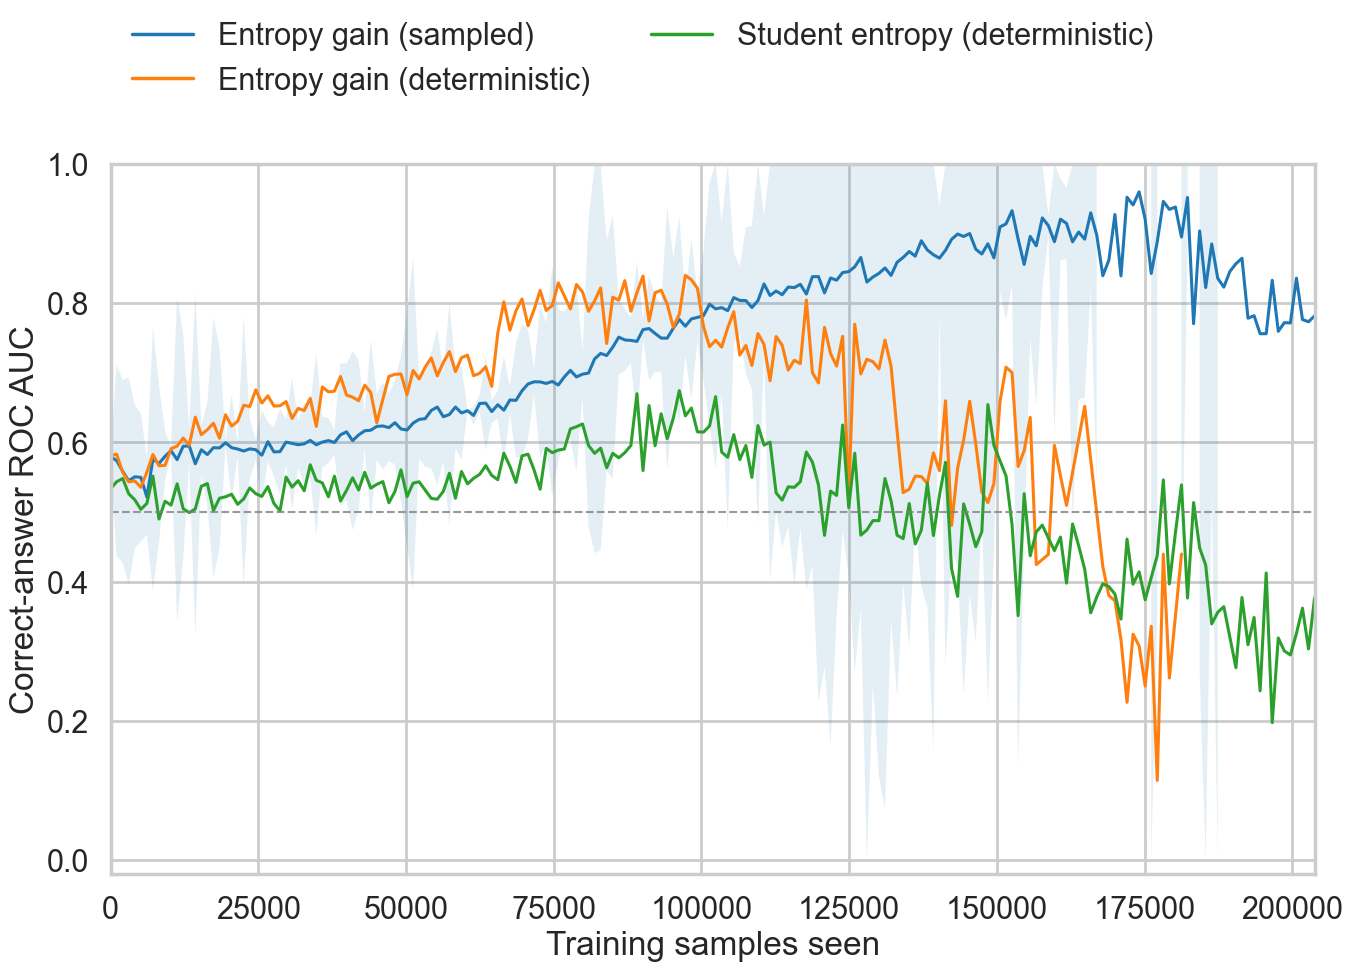

### ROC AUC within top-2,048 complexity subsets — Score: Student entropy

Individual models, left to right: Llama 3B, Phi-4 Mini, Qwen 3B.

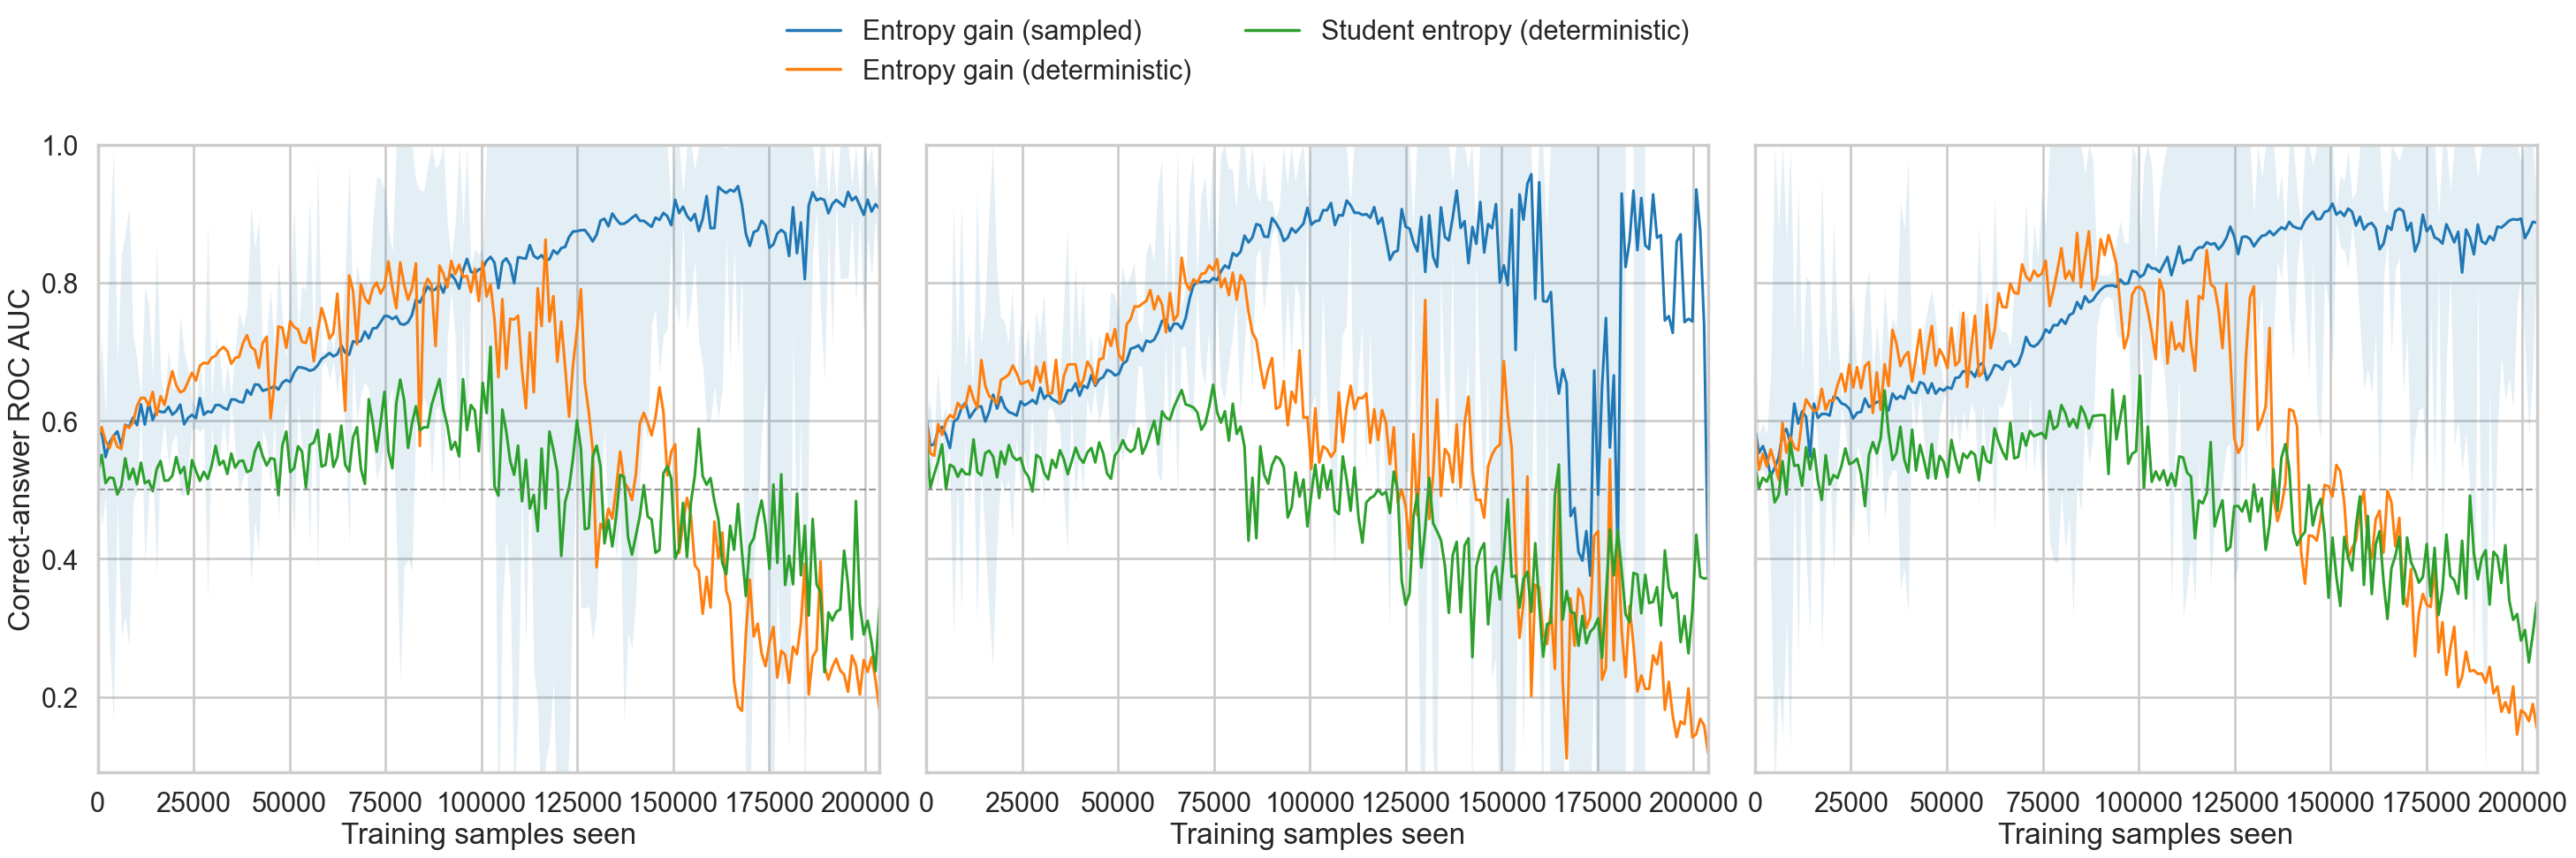

### ROC AUC within top-2,048 complexity subsets — Score: Student entropy

All models (equal-weight mean).

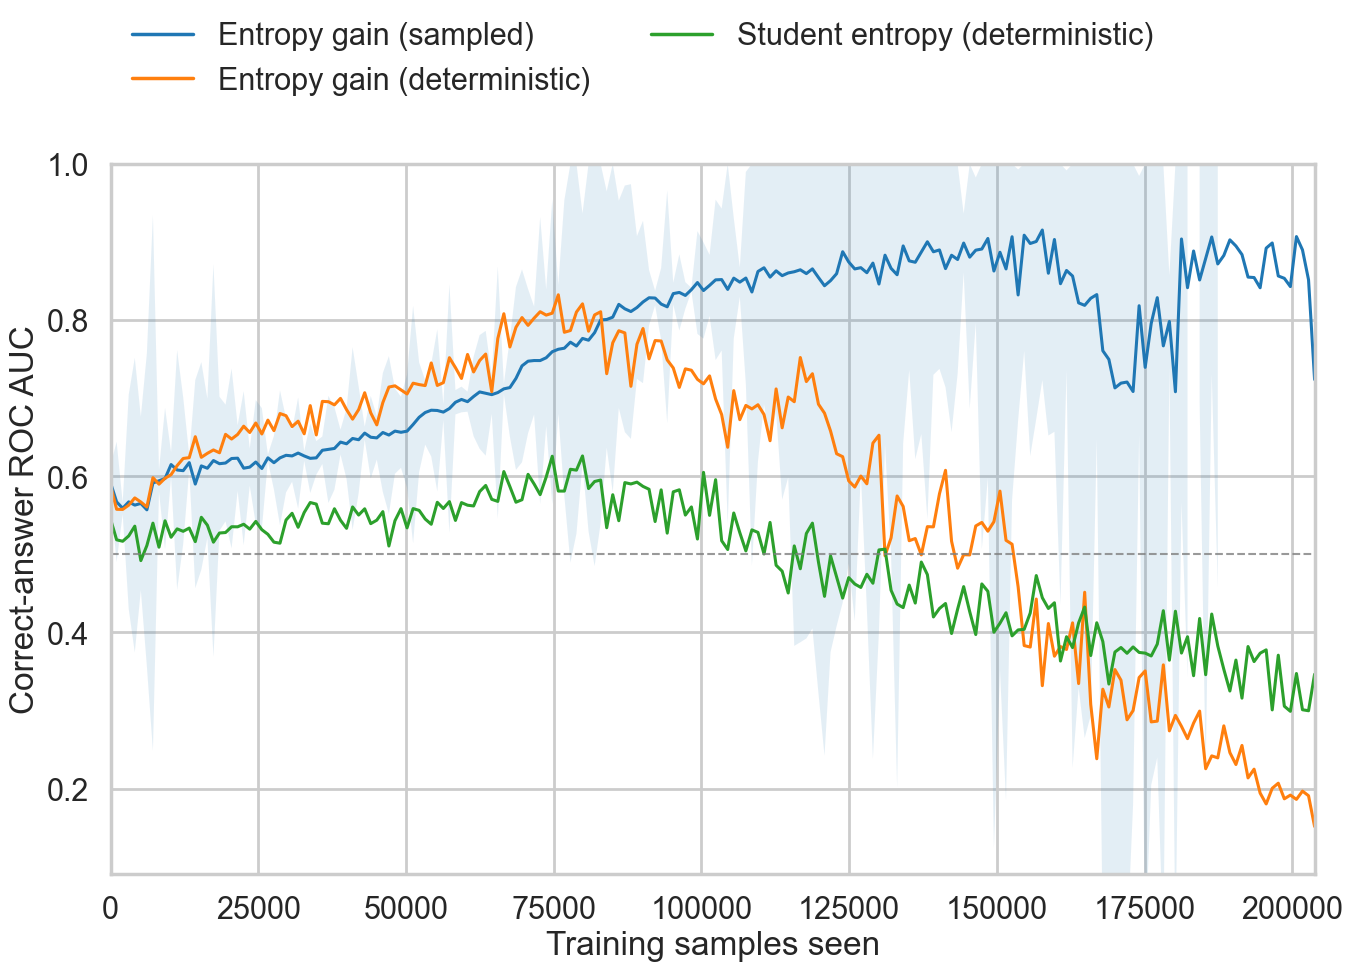

In [9]:
for subset_size in TOP_K_SUBSETS:
    subset_data = subset_roc_auc_by_epoch[subset_roc_auc_by_epoch["subset_size"] == subset_size]
    seed_subset_data = seed_subset_roc_auc_by_epoch[seed_subset_roc_auc_by_epoch["subset_size"] == subset_size]
    plot_model_comparison(
        subset_data,
        seed_subset_data,
        f"ROC AUC within top-{subset_size:,} complexity subsets",
        f"student_entropy_roc_auc_top{subset_size}",
    )
